<a href="https://colab.research.google.com/github/Ishalllll/bushfire-warning-classification/blob/main/notebooks/bushfire_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
from scipy import stats
from scipy.stats import chi2_contingency
import math
import seaborn as sns
import matplotlib.pyplot as plt
import datetime

from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from collections import Counter
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression


In [ ]:
from google.colab import drive
import os
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df_raw = pd.read_csv("/content/drive/MyDrive/Privat Datasets/Dataset PAP/Dataset Praktikum/dataset-bushfires-p2.csv")

# Exploratory Data Analysis

In [ ]:
df_raw.rename(columns={
    'Suburb'        : 'suburb',
    'Status'        : 'status',
    'Station'       : 'station',
    'DW Grass'      : 'dw_grass',
    'DW Trees'      : 'dw_trees',
    'Soil Moisture' : 'soil_moisture',
    'RH Min'        : 'RH_min',
    'Drought Index' : 'DroughtIndex',
}, inplace=True)

Records	: 1288
Columns	: 25
Duplicated	: 0
Dataframe Values: 


,Columns,Data Types,Unique,Missing Values,Missing Values(%),Distributions,Outliers,Unique Values
5,station,object,32,0,0.00,-,-,"[Werribee, Wooroloo, Tamala Park (Mindarie), M..."
2,suburb,object,194,0,0.00,-,-,"[Bailup, Wooroloo, Wanneroo, Mundaring, Nowerg..."
3,status,object,3,0,0.00,-,-,"[ADVICE, EMERGENCY WARNING, WATCH AND ACT]"
1,Date,object,335,0,0.00,-,-,"[2021-01-05, 2021-01-06, 2021-01-07, 2021-01-0..."
0,Unnamed: 0,int64,1288,0,0.00,Non-normal,0,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,..."
24,DrySpellLength,int64,15,0,0.00,Non-normal,0,"[14, 0, 1, 2, 3, 4, 6, 7, 8, 9, 10, 11, 12, 13..."
6,Minimum Temperature,float64,151,0,0.00,Non-normal,4,"[18.4, 21.3, 17.3, 20.9, 20.5, 23.2, 21.9, 23...."
16,dw_trees,float64,647,0,0.00,Non-normal,82,"[0.0655, 0.1881, 0.198, 0.216, 0.1601, 0.2718,..."
23,AntecedentRain14,float64,301,0,0.00,Non-normal,188,"[0.29, 0.0, 0.58, 0.3, 0.09, 0.03, 0.6, 0.06, ..."
22,Aspect,float64,193,0,0.00,Non-normal,24,"[180.23399706694465, 151.46236313682653, 128.6..."



Descriptive Statistics (Numeric Data Types):


,Unnamed: 0,Time,Minimum Temperature,Maximum Temperature,Rainfall,Evaporation,Sunshine,Direction Max Wind Gust,Speed Max Wind Gust,Time Max Wind Gust,...,dw_grass,dw_trees,soil_moisture,RH_min,DroughtIndex,NDMI,Slope,Aspect,AntecedentRain14,DrySpellLength
count,1288.000000,1288.000000,1288.000000,1288.000000,1288.000000,1288.000000,1288.000000,1288.000000,1288.000000,1288.000000,...,1288.000000,1288.000000,1288.000000,1288.000000,1288.000000,1288.000000,1288.000000,1288.000000,1288.000000,1288.000000
mean,643.500000,12.355590,18.200388,30.170109,0.450000,-1.317547,15.103106,128.658773,46.111801,8.951863,...,0.066853,0.151086,0.052579,28.666621,726.333851,0.028928,4.541939,175.268991,6.007275,10.415373
std,371.957883,4.046461,3.302076,4.839060,2.427641,4.518246,1.875252,128.191811,7.435498,7.481394,...,0.050362,0.136659,0.041735,12.631432,92.231620,0.074790,1.430529,21.236647,10.595080,5.022620
min,0.000000,0.000000,9.000000,18.200000,0.000000,-7.000000,3.800000,0.000000,26.000000,0.000000,...,0.021100,0.024300,0.017500,7.828000,232.000000,-0.176258,2.013233,116.198818,0.000000,0.000000
25%,321.750000,10.000000,15.900000,26.700000,0.000000,-3.000000,14.000000,0.000000,41.000000,2.000000,...,0.038500,0.047200,0.023600,20.111250,703.000000,-0.024215,3.352023,162.949073,0.070000,6.000000
50%,643.500000,12.000000,18.200000,29.900000,0.000000,-3.000000,15.000000,45.000000,46.000000,8.000000,...,0.049750,0.094400,0.034450,26.383000,769.500000,0.025563,4.374976,176.252731,1.000000,14.000000
75%,965.250000,15.000000,20.400000,33.500000,0.000000,-2.000000,16.000000,247.500000,51.000000,14.000000,...,0.072400,0.223375,0.055450,35.107000,786.000000,0.078403,5.552548,187.937469,5.557500,14.000000
max,1287.000000,24.000000,29.100000,43.900000,29.000000,22.800000,19.000000,337.500000,80.000000,24.000000,...,0.380700,0.626600,0.195600,78.008000,796.000000,0.292518,11.456913,248.930050,40.970000,14.000000



Descriptive Statistics (Object Data Types):


,Date,suburb,status,station
count,1288,1288,1288,1288
unique,335,194,3,32
top,2024-02-09,Serpentine,ADVICE,Anketell
freq,22,54,949,174



Distributions Visualization (Numeric Data Types):


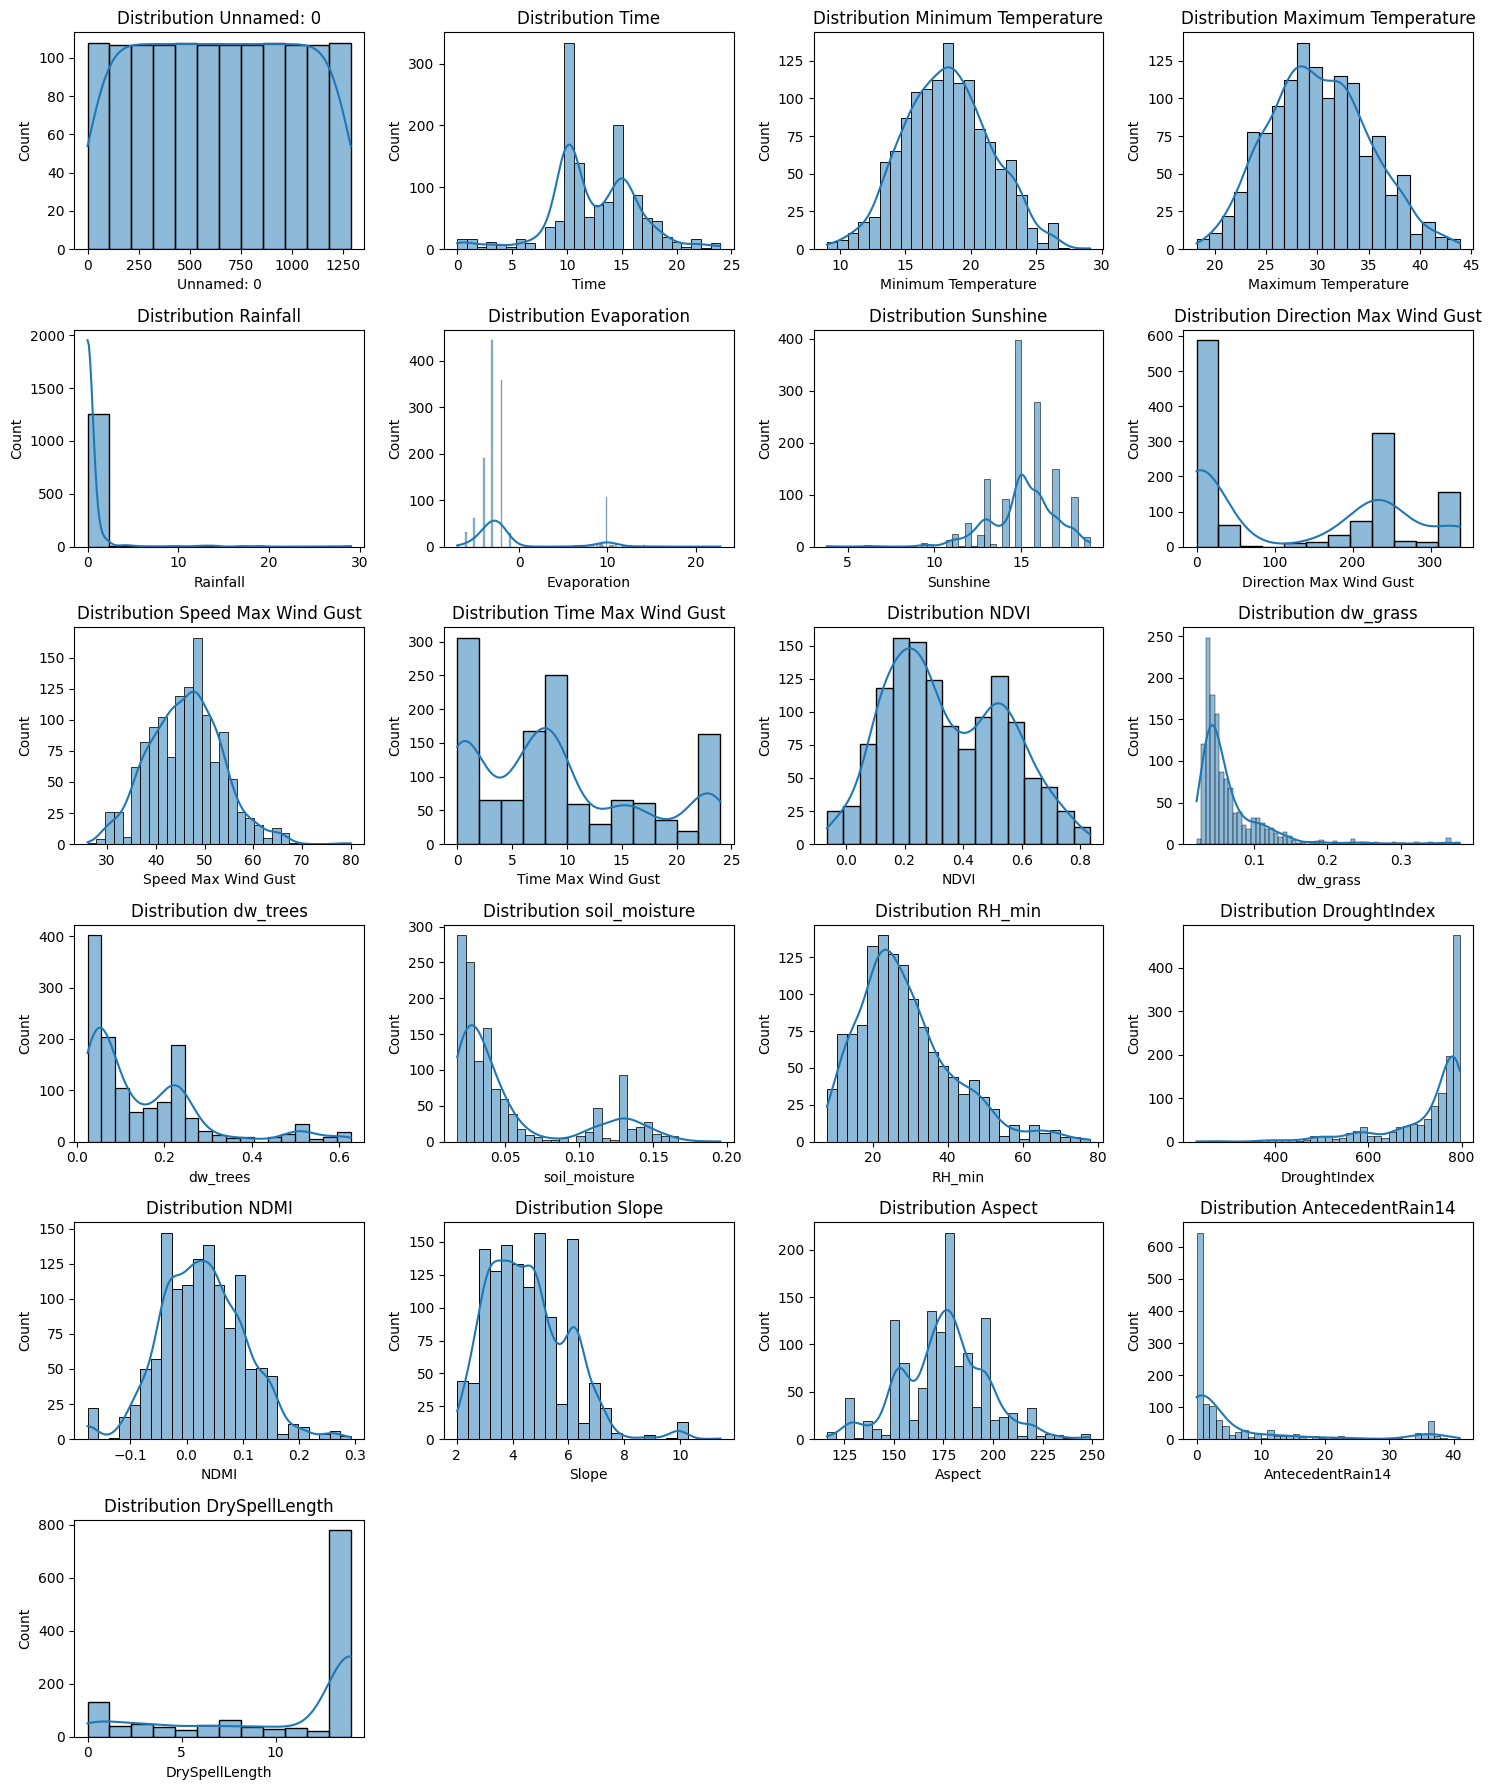


Heatmap:


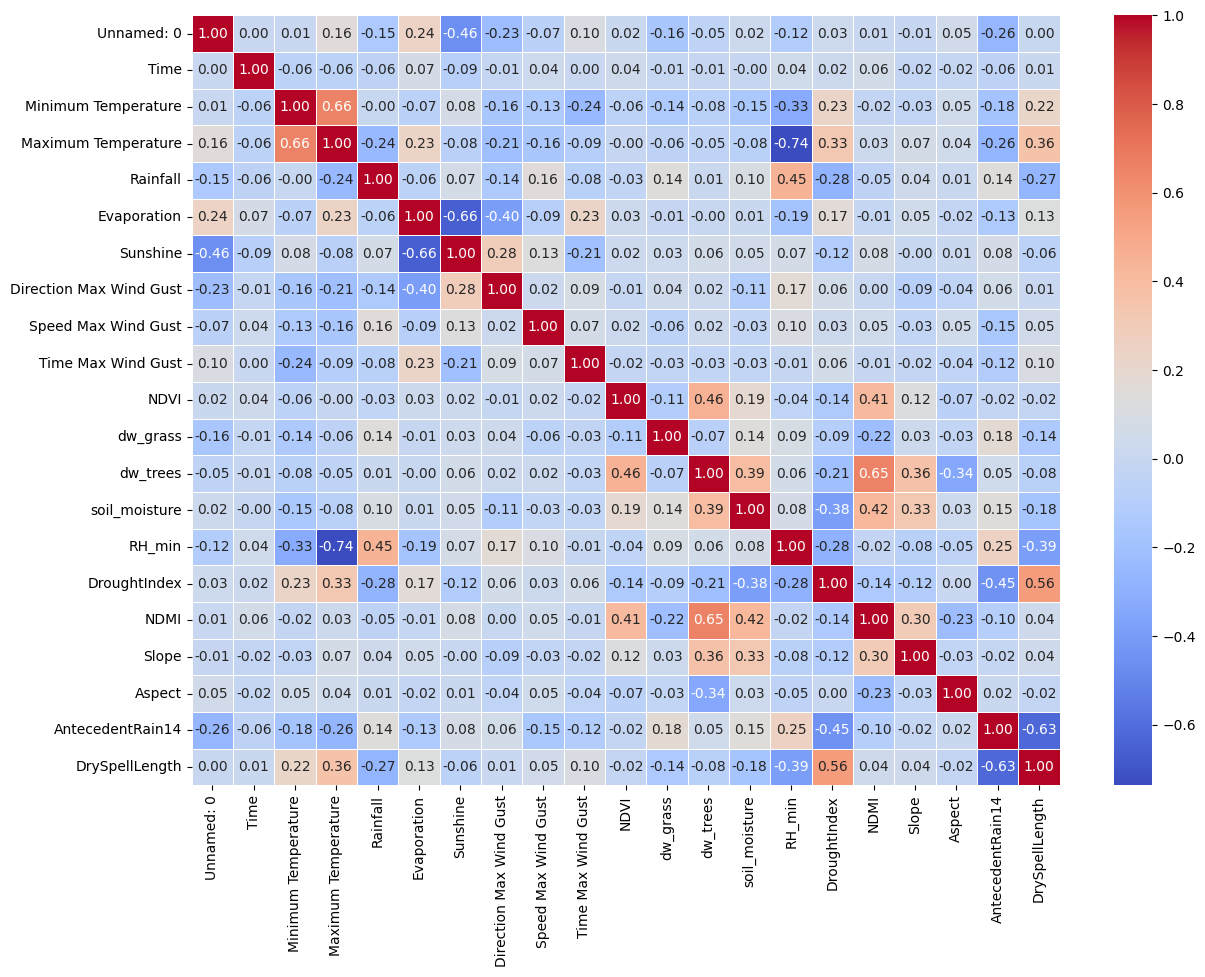

In [ ]:
def data_understanding(df):
  prepare = []
  for column in df.columns:
    # Identifikasi missing values
    percent_missing = (df[column].isnull().sum()/len(df[column]))*100

    # Identifikasi bentuk distribusi
    if pd.api.types.is_numeric_dtype(df[column]):
      stat_,p_value = stats.shapiro(df[column].dropna())
      distrib = "Normal" if p_value > 0.05 else "Non-normal"
    else:
      distrib = '-'

    # Identifikasi outliers
    if pd.api.types.is_numeric_dtype(df[column]):
      q1 = np.quantile(df[column].dropna(),0.25)
      q3 = np.quantile(df[column].dropna(),0.75)
      iqr = q3 - q1

      delta = 1.5 * iqr
      lower_bound = q1 - delta
      upper_bound = q3 + delta
      outliers = (df[column] < lower_bound) | (df[column] > upper_bound)
      outliers_sum = df[column][outliers].count()
    else:
      outliers_sum = '-'

    prepare.append(
        [
            column,
            df[column].dtype,
            df[column].nunique(),
            df[column].isnull().sum(),
            f"{percent_missing:.2f}",
            distrib,
            outliers_sum,
            df[column].unique()
        ]
    )
  print(f"Records\t: {df.shape[0]}")
  print(f"Columns\t: {df.shape[1]}")
  print(f"Duplicated\t: {df.duplicated().sum()}")
  print('Dataframe Values: ')
  dfv = pd.DataFrame(prepare,columns = ['Columns','Data Types','Unique','Missing Values','Missing Values(%)','Distributions','Outliers','Unique Values'])
  dfv['Data Types'] = dfv['Data Types'].astype(str)
  display(dfv.sort_values("Data Types", ascending = False))

  print(f"="*180,"\n")
  print('Descriptive Statistics (Numeric Data Types):')
  display(df.describe())
  print(f"="*180,"\n")
  print('Descriptive Statistics (Object Data Types):')
  display(df.describe(include='O'))
  print(f"="*180,"\n")

  print('Distributions Visualization (Numeric Data Types):')
  numeric_cols = df.select_dtypes(include='number').columns

  cols_per_row = 4
  n_cols = len(numeric_cols)
  n_rows = math.ceil(n_cols / cols_per_row)

  fig, axes = plt.subplots(n_rows, cols_per_row, figsize=(15, 3 * n_rows))
  axes = axes.flatten()

  for i, col in enumerate(numeric_cols):
      sns.histplot(df[col].dropna(), kde=True, ax=axes[i])
      axes[i].set_title(f'Distribution {col}')

  for j in range(i + 1, len(axes)):
      axes[j].set_visible(False)

  plt.tight_layout()
  plt.show()

  print(f"="*180,"\n")
  print('Heatmap:')
  plt.figure(figsize=(14, 10))
  sns.heatmap(df.select_dtypes(include='number').corr(),fmt='.2f',annot=True,cmap='coolwarm',linewidths=0.5)


data_understanding(df_raw)

In [ ]:
# Target label distributions
print("Target Class Distribution:")
print(f'{df_raw['status'].value_counts()}\n')

print("Percentage:")
print(f'{df_raw['status'].value_counts(normalize=True).round(3)*100}')

Target Class Distribution:
status
ADVICE               949
WATCH AND ACT        230
EMERGENCY WARNING    109
Name: count, dtype: int64

Percentage:
status
ADVICE               73.7
WATCH AND ACT        17.9
EMERGENCY WARNING     8.5
Name: proportion, dtype: float64


# Data Preprocessing

In [ ]:
df_clean = df_raw.copy()

## Feature Engineering

### Feature Creation

In [ ]:
df_clean['Date'] = pd.to_datetime(df_clean['Date'])

df_clean['year'] = df_clean['Date'].dt.year
df_clean['day_of_year'] = df_clean['Date'].dt.day_of_year
df_clean['month'] = df_clean['Date'].dt.month
df_clean['day'] = df_clean['Date'].dt.day
df_clean['day_of_week'] = df_clean['Date'].dt.dayofweek
df_clean['year_month'] = df_clean['Date'].dt.to_period('M').astype(str)

In [ ]:
# Membuat cyclical feature encoding karena "Bulan" bukan bersifat linear, melainkan sirkular
df_clean['month_sin'] = np.sin(2 * np.pi * df_clean['month'] / 12)
df_clean['month_cos'] = np.cos(2 * np.pi * df_clean['month'] / 12)

In [ ]:
# Membuat Cyclical Feature untuk Time
df_clean['time_sin'] = np.sin(2 * np.pi * df_clean['Time'] / 24)
df_clean['time_cos'] = np.cos(2 * np.pi * df_clean['Time'] / 24)

In [ ]:
# Membuat Cyclical Feature untuk day of year
df_clean['doy_sin'] = np.sin(2 * np.pi * df_clean['day_of_year'] / 365)
df_clean['doy_cos'] = np.cos(2 * np.pi * df_clean['day_of_year'] / 365)

In [ ]:
# Membuat cyclical feature untuk Time Max Wind Gust
df_clean['time_wind_sin'] = np.sin(2 * np.pi * df_clean['Time Max Wind Gust'] / 24)
df_clean['time_wind_cos'] = np.cos(2 * np.pi * df_clean['Time Max Wind Gust'] / 24)

In [ ]:
# Membuat cyclical feature encoding untuk Direction Max Wind Gust
df_clean['wind_sin'] = np.sin(2 * np.pi * df_clean['Direction Max Wind Gust'] / 360)
df_clean['wind_cos'] = np.cos(2 * np.pi * df_clean['Direction Max Wind Gust'] / 360)

In [ ]:
# Membuat data bining untuk Aspect
def bining_aspect(sudut):
    if (315 <= sudut <= 360) or (0 <= sudut < 45):
        return 'North'
    elif 45 <= sudut < 135:
        return 'East'
    elif 135 <= sudut < 225:
        return 'South'
    else:
        return 'West'

df_clean['aspect_category'] = df_clean['Aspect'].apply(bining_aspect)

In [ ]:
mapping_musim = {
    12: "Summer", 1: "Summer", 2: "Summer",
    3: "Autumn", 4: "Autumn", 5: "Autumn",
    6: "Winter", 7: "Winter", 8: "Winter",
    9: "Spring", 10: "Spring", 11: "Spring"
}

df_clean['season'] = df_clean['month'].map(mapping_musim)

Records	: 1288
Columns	: 43
Duplicated	: 0
Dataframe Values: 


,Columns,Data Types,Unique,Missing Values,Missing Values(%),Distributions,Outliers,Unique Values
42,season,object,3,0,0.00,-,-,"[Summer, Autumn, Spring]"
2,suburb,object,194,0,0.00,-,-,"[Bailup, Wooroloo, Wanneroo, Mundaring, Nowerg..."
3,status,object,3,0,0.00,-,-,"[ADVICE, EMERGENCY WARNING, WATCH AND ACT]"
41,aspect_category,object,3,0,0.00,-,-,"[South, East, West]"
5,station,object,32,0,0.00,-,-,"[Werribee, Wooroloo, Tamala Park (Mindarie), M..."
30,year_month,object,25,0,0.00,-,-,"[2021-01, 2021-02, 2021-03, 2021-11, 2021-12, ..."
24,DrySpellLength,int64,15,0,0.00,Non-normal,0,"[14, 0, 1, 2, 3, 4, 6, 7, 8, 9, 10, 11, 12, 13..."
0,Unnamed: 0,int64,1288,0,0.00,Non-normal,0,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,..."
25,year,int32,5,0,0.00,Non-normal,0,"[2021, 2022, 2023, 2024, 2025]"
26,day_of_year,int32,146,0,0.00,Non-normal,0,"[5, 6, 7, 9, 10, 11, 12, 13, 14, 18, 19, 20, 2..."



Descriptive Statistics (Numeric Data Types):


,Unnamed: 0,Date,Time,Minimum Temperature,Maximum Temperature,Rainfall,Evaporation,Sunshine,Direction Max Wind Gust,Speed Max Wind Gust,...,month_sin,month_cos,time_sin,time_cos,doy_sin,doy_cos,time_wind_sin,time_wind_cos,wind_sin,wind_cos
count,1288.000000,1288,1288.000000,1288.000000,1288.000000,1288.000000,1288.000000,1288.000000,1288.000000,1288.000000,...,1.288000e+03,1.288000e+03,1.288000e+03,1288.000000,1288.000000,1288.000000,1288.000000,1.288000e+03,1288.000000,1288.000000
mean,643.500000,2023-04-01 04:13:47.329192448,12.355590,18.200388,30.170109,0.450000,-1.317547,15.103106,128.658773,46.111801,...,4.245938e-01,6.876975e-01,-7.329315e-02,-0.603914,0.246959,0.782439,0.247928,1.674846e-01,-0.232339,0.370692
min,0.000000,2021-01-05 00:00:00,0.000000,9.000000,18.200000,0.000000,-7.000000,3.800000,0.000000,26.000000,...,-5.000000e-01,6.123234e-17,-1.000000e+00,-1.000000,-0.858764,0.004304,-1.000000,-1.000000e+00,-1.000000,-1.000000
25%,321.750000,2021-12-28 12:00:00,10.000000,15.900000,26.700000,0.000000,-3.000000,14.000000,0.000000,41.000000,...,-2.449294e-16,5.000000e-01,-7.071068e-01,-0.866025,-0.171293,0.664855,-0.258819,-5.000000e-01,-0.707107,-0.382683
50%,643.500000,2023-11-08 00:00:00,12.000000,18.200000,29.900000,0.000000,-3.000000,15.000000,45.000000,46.000000,...,5.000000e-01,8.660254e-01,1.224647e-16,-0.866025,0.337523,0.852078,0.258819,6.123234e-17,0.000000,0.923880
75%,965.250000,2024-03-09 06:00:00,15.000000,20.400000,33.500000,0.000000,-2.000000,16.000000,247.500000,51.000000,...,8.660254e-01,8.660254e-01,5.000000e-01,-0.500000,0.687053,0.966848,0.866025,9.659258e-01,0.000000,1.000000
max,1287.000000,2025-12-31 00:00:00,24.000000,29.100000,43.900000,29.000000,22.800000,19.000000,337.500000,80.000000,...,1.000000e+00,1.000000e+00,1.000000e+00,1.000000,0.999991,1.000000,1.000000,1.000000e+00,0.923880,1.000000
std,371.957883,NaN,4.046461,3.302076,4.839060,2.427641,4.518246,1.875252,128.191811,7.435498,...,4.935871e-01,3.216108e-01,6.193030e-01,0.496859,0.522174,0.233216,0.599186,7.430776e-01,0.470042,0.767004



Descriptive Statistics (Object Data Types):


,suburb,status,station,year_month,aspect_category,season
count,1288,1288,1288,1288,1288,1288
unique,194,3,32,25,3,3
top,Serpentine,ADVICE,Anketell,2021-02,South,Summer
freq,54,949,174,147,1220,964



Distributions Visualization (Numeric Data Types):


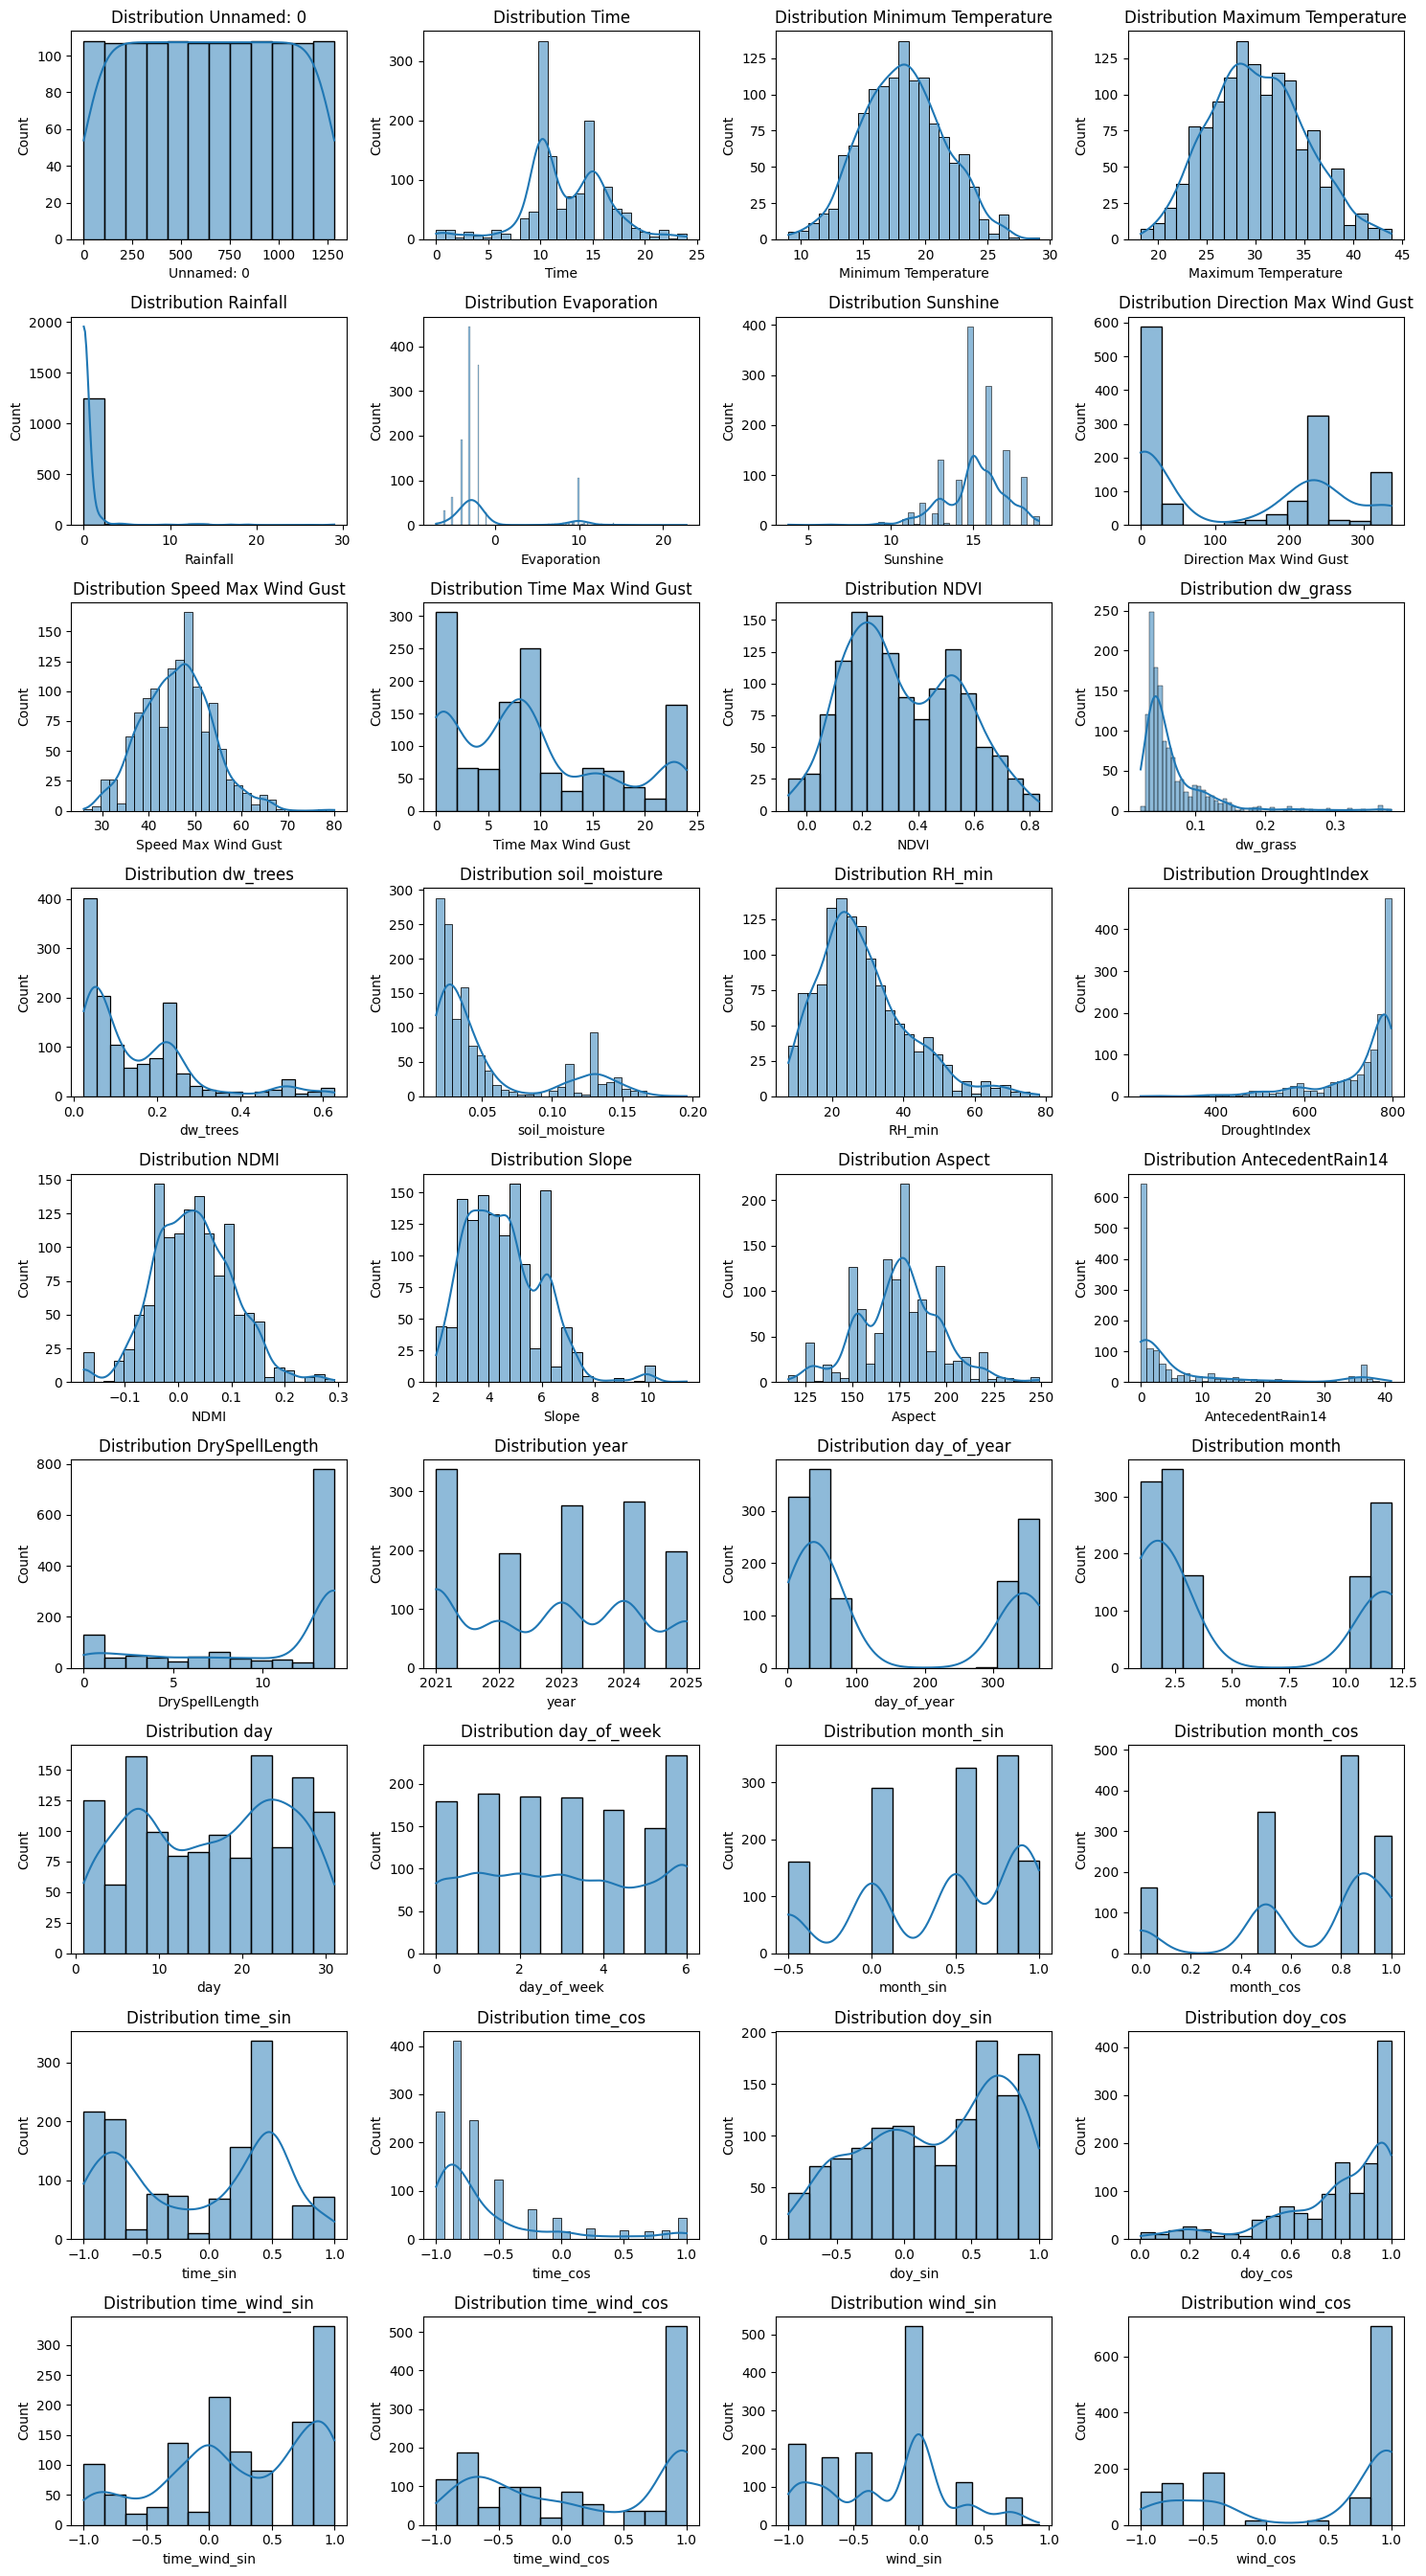


Heatmap:


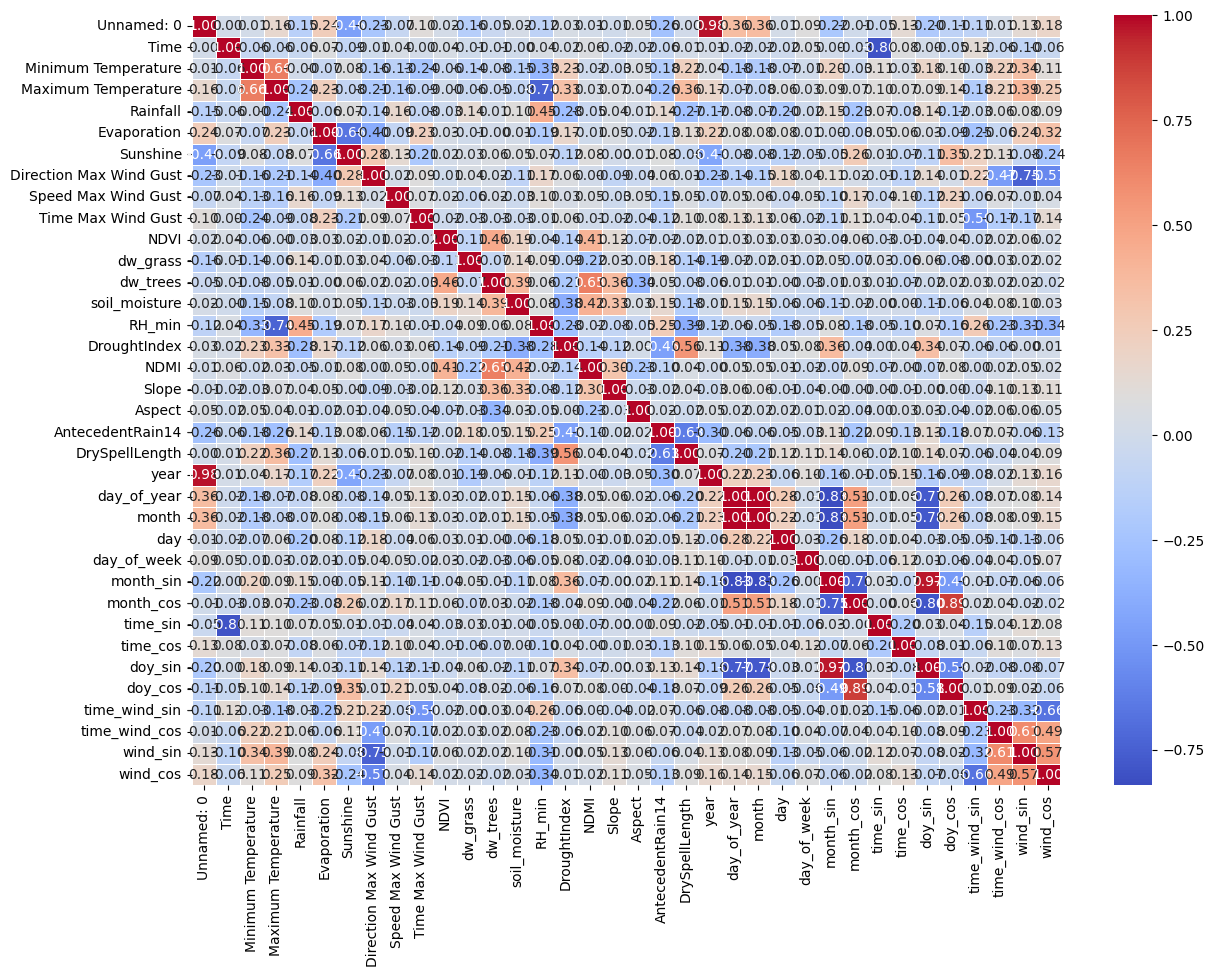

In [ ]:
data_understanding(df_clean)

### Feature selection

In [ ]:
df_clean.drop([
    "Unnamed: 0",
    "month",
    "day_of_year",
    "Time",
    "Time Max Wind Gust",
    "Direction Max Wind Gust",
    "Aspect",
    "Date",
],axis=1,inplace=True, errors='ignore')

In [ ]:
numerical_cols = df_clean.select_dtypes(include='number')
categorical_cols = df_clean.select_dtypes(include='O').drop(columns=['status'])

#### Numeric Dtypes

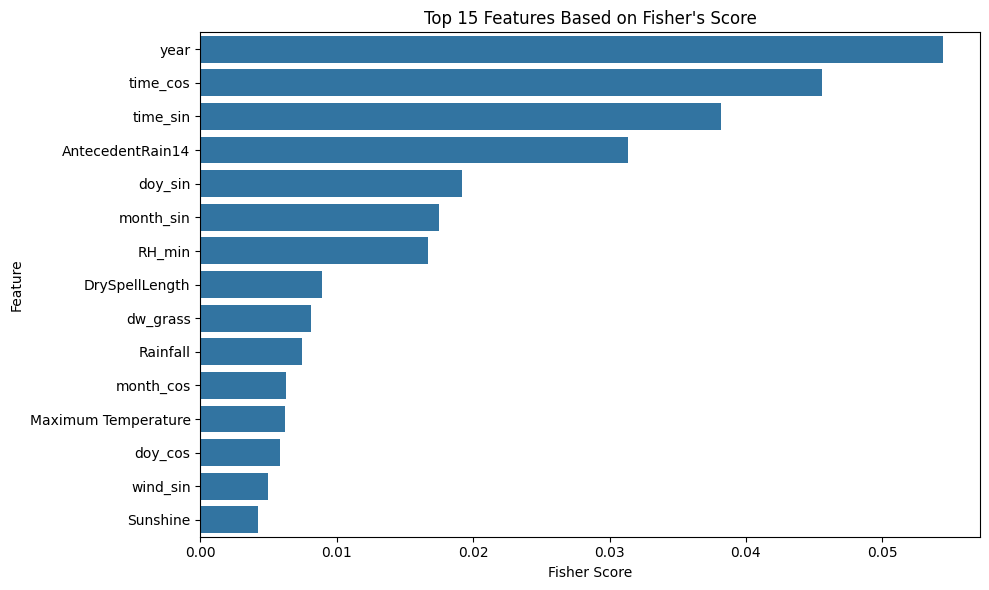

In [ ]:
target = 'status'
y = df_clean[target]


def fisher_score(X, y):
    scores = {}

    for col in X.columns:
        x = X[col]
        x = pd.to_numeric(x, errors='coerce')

        overall_mean = x.mean()

        numerator = 0
        denominator = 0

        for cls in y.unique():
            x_class = x[y == cls]
            n_class = len(x_class)

            if n_class == 0:
                continue

            mean_class = x_class.mean()
            var_class = x_class.var(ddof=0)

            numerator += n_class * (mean_class - overall_mean) ** 2
            denominator += n_class * var_class

        if denominator == 0 or pd.isna(denominator):
            scores[col] = 0
        else:
            scores[col] = numerator/denominator

    return pd.Series(scores).sort_values(ascending=False)


scores = fisher_score(numerical_cols, y)

top_scores = scores.head(15)

plt.figure(figsize=(10, 6))
sns.barplot(
    x=top_scores.values,
    y=top_scores.index
)

plt.title("Top 15 Features Based on Fisher's Score")
plt.xlabel("Fisher Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

#### Categorical Dtypes

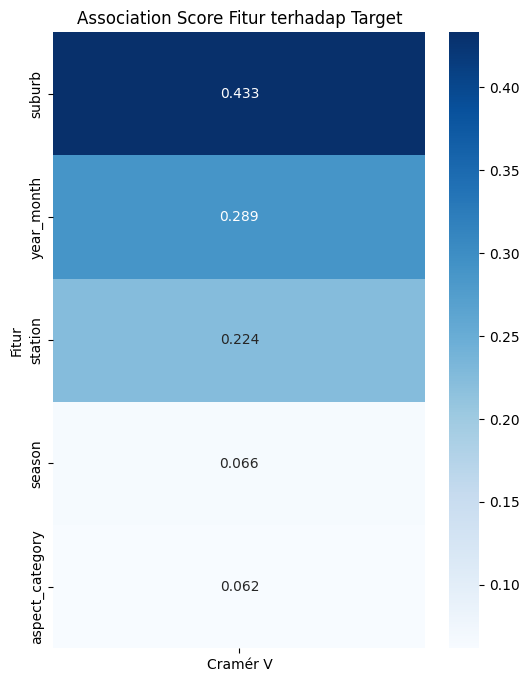

In [ ]:
def cramers_v(col_fitur, col_target):
    # Langkah 1: buat tabel silang (frekuensi observasi)
    tabel = pd.crosstab(col_fitur, col_target)

    # Langkah 2: jalankan Chi-Square
    chi2, p_value, dof, expected = chi2_contingency(tabel)

    # Langkah 3: hitung Cramér's V dari hasil Chi-Square
    n = len(col_fitur)
    k = min(tabel.shape) - 1
    v = np.sqrt(chi2 / (n * k))

    return chi2, p_value, v

# Fitur kategorikal yang diuji

results = []
for col in categorical_cols:
    chi2, p_value, v = cramers_v(df_clean[col], df_clean['status'])
    results.append({
        'Fitur':col,
        'Chi-Square':round(chi2, 4),
        'p-value':round(p_value, 4),
        'Cramér V':round(v, 4)
    })

df_results = pd.DataFrame(results).sort_values('Cramér V', ascending=False)

heatmap_data = df_results.set_index("Fitur")[["Cramér V"]]

plt.figure(figsize=(6, 8))
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".3f",
    cmap="Blues"
)

plt.title("Association Score Fitur terhadap Target")
plt.show()

In [ ]:
# Hasil feature selection
hasil_seleksi = [
    "time_cos",
    "time_sin",
    "AntecedentRain14",
    "doy_cos",
    "doy_sin",
    "month_sin",
    "month_cos",
    "RH_min",
    "DrySpellLength",
    "dw_grass",
    "Rainfall",
    "Maximum Temperature",
    "wind_sin",
    "wind_cos",
    "Sunshine",
    "suburb",
    "year_month",
    "station",
    "status"
]

In [ ]:
df_clean = df_clean[hasil_seleksi]

## Duplicates Handling

In [ ]:
df_clean.duplicated().sum()

np.int64(0)

## Outlier Handling

In [ ]:
# Pembagian data
x = df_clean.drop(columns='status')
y = df_clean['status']

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, stratify=y, random_state=42
)

class IQRCapper(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        X = np.array(X)
        Q1 = np.percentile(X, 25, axis=0)
        Q3 = np.percentile(X, 75, axis=0)
        IQR = Q3 - Q1
        self.lower_ = Q1 - 1.5 * IQR
        self.upper_ = Q3 + 1.5 * IQR
        return self

    def transform(self, X, y=None):
        X = np.array(X).copy()
        for i in range(X.shape[1]):
            X[:, i] = np.clip(X[:, i], self.lower_[i], self.upper_[i])
        return X

## Scaling & Encode

In [ ]:
target_encoder = LabelEncoder()
y_train_encoded = target_encoder.fit_transform(y_train)
y_test_encoded = target_encoder.transform(y_test)

# Frequency encoding
freq_cols = ['suburb', 'station', 'year_month']
freq_maps = {}

for col in freq_cols:
    freq_maps[col] = X_train[col].value_counts(normalize=True)
    X_train[col + '_freq'] = X_train[col].map(freq_maps[col])
    X_test[col + '_freq'] = X_test[col].map(freq_maps[col]).fillna(freq_maps[col].min())

# Drop kolom string aslinya
X_train = X_train.drop(columns=freq_cols)
X_test = X_test.drop(columns=freq_cols)

numerical_cols = X_train.select_dtypes(include='number').columns.tolist()

preprocessor = ColumnTransformer([
    ('num', Pipeline([
        ('capper', IQRCapper()),
        ('scaler', StandardScaler())
    ]), numerical_cols)
])

## SMOTE

In [ ]:
# Hitung distribusi kelas dari y_train_encoded
class_counts = Counter(y_train_encoded)
n_majority = max(class_counts.values())

print("Distribusi kelas training:")
for cls, count in sorted(class_counts.items()):
    print(f"  Kelas {cls}: {count} sampel")

# Custom sampling strategy
sampling_strategy = {}
for cls, count in class_counts.items():
    if count == n_majority:
        sampling_strategy[cls] = count                        # mayoritas: tidak disentuh
    elif count == min(class_counts.values()):
        sampling_strategy[cls] = max(count, int(0.4 * n_majority))  # terkecil: boost ke 40%
    else:
        sampling_strategy[cls] = max(count, int(0.6 * n_majority))  # tengah: boost ke 60%

print("\nTarget setelah SMOTE:")
for cls, target in sorted(sampling_strategy.items()):
    orig = class_counts[cls]
    print(f"  Kelas {cls}: {orig} → {target} (+{target - orig})")

Distribusi kelas training:
  Kelas 0: 759 sampel
  Kelas 1: 87 sampel
  Kelas 2: 184 sampel

Target setelah SMOTE:
  Kelas 0: 759 → 759 (+0)
  Kelas 1: 87 → 303 (+216)
  Kelas 2: 184 → 455 (+271)


# Modeling

In [ ]:
candidates = {

    'Random Forest': {
        'classifier': RandomForestClassifier(random_state=42),
        'params': {
            'classifier__n_estimators': [100, 200],
            'classifier__max_depth': [None, 10, 20],
            'classifier__min_samples_split': [2, 5],
            'classifier__class_weight': ['balanced']
        }
    },

    'XGBoost': {
        'classifier': XGBClassifier(
            random_state=42,
            eval_metric='mlogloss',
            verbosity=0
        ),
        'params': {
            'classifier__n_estimators': [100, 200],
            'classifier__max_depth': [3, 5, 7],
            'classifier__learning_rate': [0.05, 0.1],
            'classifier__subsample': [0.8, 1.0]
        }
    },

    'SVM': {
        'classifier': SVC(random_state=42),
        'params': {
            'classifier__C': [0.1, 1, 10],
            'classifier__kernel': ['rbf'],
            'classifier__gamma': ['scale', 'auto'],
            'classifier__class_weight': ['balanced']
        }
    }
}

In [ ]:
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
results = {}

for name, config in candidates.items():
    print(f"\n{'='*50}")
    print(f"Training: {name}")
    print('='*50)

    # Buat pipeline baru per model
    pipeline = ImbPipeline([
        ('preprocessor', preprocessor),
        ('smote', SMOTE(
            sampling_strategy=sampling_strategy,
            k_neighbors=5,
            random_state=42
        )),
        ('classifier', config['classifier'])
    ])

    grid = GridSearchCV(
        estimator=pipeline,
        param_grid=config['params'],
        cv=cv,
        scoring='f1_macro',
        n_jobs=-1,
        verbose=1
    )

    grid.fit(X_train, y_train_encoded)
    y_pred = grid.best_estimator_.predict(X_test)

    results[name] = {
        'best_params': grid.best_params_,
        'cv_score': round(grid.best_score_, 4),
        'test_acc': round(accuracy_score(y_test_encoded, y_pred), 4),
        'test_f1': round(f1_score(y_test_encoded, y_pred, average='macro'), 4),
        'best_estimator': grid.best_estimator_,
        'y_pred': y_pred
    }

    print(f"Best Params : {grid.best_params_}")
    print(f"CV F1 Macro : {grid.best_score_:.4f}")
    print(f"Test Acc    : {results[name]['test_acc']}")
    print(f"Test F1     : {results[name]['test_f1']}")


Training: Random Forest
Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best Params : {'classifier__class_weight': 'balanced', 'classifier__max_depth': 10, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 200}
CV F1 Macro : 0.7518
Test Acc    : 0.8915
Test F1     : 0.8213

Training: XGBoost
Fitting 3 folds for each of 24 candidates, totalling 72 fits
Best Params : {'classifier__learning_rate': 0.1, 'classifier__max_depth': 7, 'classifier__n_estimators': 200, 'classifier__subsample': 1.0}
CV F1 Macro : 0.7413
Test Acc    : 0.8992
Test F1     : 0.804

Training: SVM
Fitting 3 folds for each of 6 candidates, totalling 18 fits
Best Params : {'classifier__C': 10, 'classifier__class_weight': 'balanced', 'classifier__gamma': 'scale', 'classifier__kernel': 'rbf'}
CV F1 Macro : 0.6388
Test Acc    : 0.8023
Test F1     : 0.667


# Evaluation

In [ ]:
df_results = pd.DataFrame({
    name: {
        'CV F1 Macro':   v['cv_score'],
        'Test Accuracy': v['test_acc'],
        'Test F1 Macro': v['test_f1']
    }
    for name, v in results.items()
}).T.sort_values('Test F1 Macro', ascending=False)

print("Perbandingan Model")
display(df_results)

Perbandingan Model


,CV F1 Macro,Test Accuracy,Test F1 Macro
Random Forest,0.7518,0.8915,0.8213
XGBoost,0.7413,0.8992,0.8040
SVM,0.6388,0.8023,0.6670


In [ ]:
for name, v in results.items():
    print(f"\n{'='*50}")
    print(f"Classification Report: {name}")
    print('='*50)
    print(classification_report(
        y_test_encoded,
        v['y_pred'],
        target_names=target_encoder.classes_
    ))


Classification Report: Random Forest
                   precision    recall  f1-score   support

           ADVICE       0.93      0.95      0.94       190
EMERGENCY WARNING       0.81      0.77      0.79        22
    WATCH AND ACT       0.75      0.72      0.73        46

         accuracy                           0.89       258
        macro avg       0.83      0.81      0.82       258
     weighted avg       0.89      0.89      0.89       258


Classification Report: XGBoost
                   precision    recall  f1-score   support

           ADVICE       0.93      0.97      0.95       190
EMERGENCY WARNING       0.75      0.68      0.71        22
    WATCH AND ACT       0.80      0.70      0.74        46

         accuracy                           0.90       258
        macro avg       0.83      0.78      0.80       258
     weighted avg       0.89      0.90      0.90       258


Classification Report: SVM
                   precision    recall  f1-score   support

          

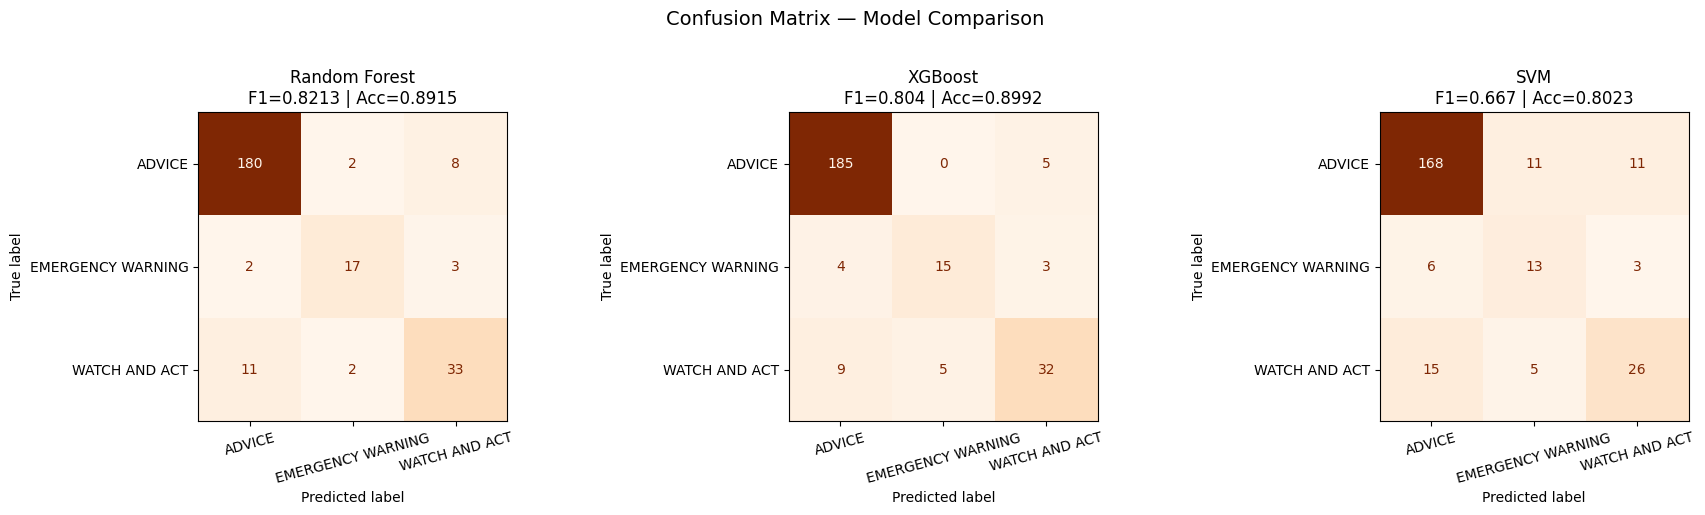

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, v) in zip(axes, results.items()):
    cm = confusion_matrix(y_test_encoded, v['y_pred'])
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=target_encoder.classes_
    )
    disp.plot(cmap='Oranges', ax=ax, colorbar=False)
    ax.set_title(f'{name}\nF1={v["test_f1"]} | Acc={v["test_acc"]}')
    ax.tick_params(axis='x', rotation=15)

plt.suptitle('Confusion Matrix — Model Comparison', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

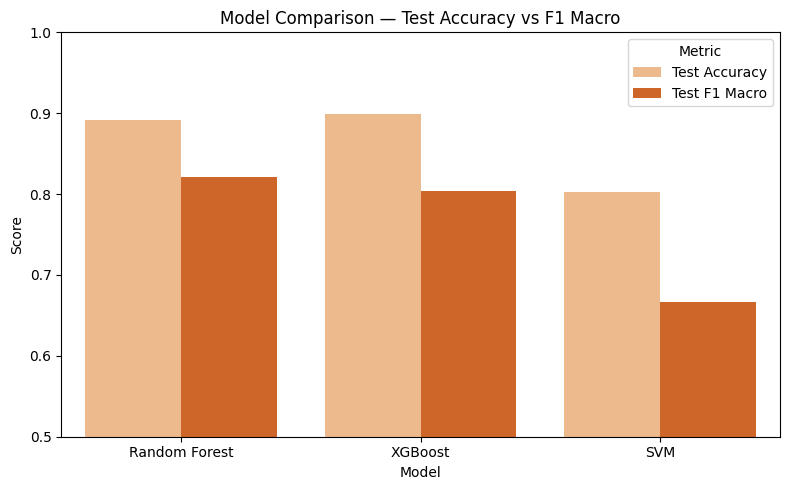

In [ ]:
df_plot = df_results[['Test Accuracy', 'Test F1 Macro']].reset_index()
df_plot = df_plot.melt(id_vars='index', var_name='Metric', value_name='Score')

plt.figure(figsize=(8, 5))
sns.barplot(data=df_plot, x='index', y='Score', hue='Metric', palette='Oranges')
plt.title('Model Comparison — Test Accuracy vs F1 Macro')
plt.xlabel('Model')
plt.ylabel('Score')
plt.ylim(0.5, 1.0)
plt.legend(title='Metric')
plt.tight_layout()
plt.show()

# Hyperparameter Tuning Stacking

In [ ]:
base_learners = [
    ('rf', RandomForestClassifier(
        n_estimators=200, max_depth=10,
        class_weight='balanced',
        random_state=42, n_jobs=-1
    )),
    ('xgb', XGBClassifier(
        n_estimators=200, max_depth=5, learning_rate=0.1,
        eval_metric='mlogloss', verbosity=0,
        random_state=42
    )),
    ('svm', SVC(
        C=1, kernel='rbf', gamma='scale',
        class_weight='balanced',
        random_state=42
    ))
]

In [ ]:
pipeline_stacking = ImbPipeline([
    ('preprocessor', preprocessor),
    ('smote', SMOTE(
        sampling_strategy=sampling_strategy,
        k_neighbors=5,
        random_state=42
    )),
    ('classifier', StackingClassifier(
        estimators=base_learners,
        final_estimator=LogisticRegression(max_iter=1000, random_state=42),
        cv=5,
        n_jobs=-1
    ))
])

In [ ]:
param_grid = {
  'classifier__final_estimator__C':[0.1, 1, 10],
  'classifier__passthrough':[False, True]
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

grid = GridSearchCV(
    estimator = pipeline_stacking,
    param_grid = param_grid,
    cv = cv,
    scoring = 'f1_macro',
    n_jobs = -1,
    verbose = 1
)

grid.fit(X_train, y_train_encoded)
y_pred = grid.best_estimator_.predict(X_test)

results = {
    'Stacking (Tuned)': {
        'best_params': grid.best_params_,
        'cv_score': round(grid.best_score_, 4),
        'test_acc': round(accuracy_score(y_test_encoded, y_pred), 4),
        'test_f1': round(f1_score(y_test_encoded, y_pred, average='macro'), 4),
        'y_pred': y_pred
    }
}

print(f"\nBest Params :{grid.best_params_}")
print(f"CV F1 Macro :{grid.best_score_:.4f}")
print(f"Test Acc    :{results['Stacking (Tuned)']['test_acc']}")
print(f"Test F1     :{results['Stacking (Tuned)']['test_f1']}")


Fitting 3 folds for each of 6 candidates, totalling 18 fits

Best Params :{'classifier__final_estimator__C': 10, 'classifier__passthrough': True}
CV F1 Macro :0.6556
Test Acc    :0.8585
Test F1     :0.7398


In [ ]:
df_results = pd.DataFrame({
    name: {
        'CV F1 Macro': v['cv_score'],
        'Test Accuracy': v['test_acc'],
        'Test F1 Macro': v['test_f1']
    }
    for name, v in results.items()
}).T.sort_values('Test F1 Macro', ascending=False)

print("Perbandingan Model")
display(df_results)

Perbandingan Model


,CV F1 Macro,Test Accuracy,Test F1 Macro
Stacking (Tuned),0.6556,0.8585,0.7398


In [ ]:
for name, v in results.items():
    print(f"\n{'='*50}")
    print(f"Classification Report: {name}")
    print('='*50)
    print(classification_report(
        y_test_encoded,
        v['y_pred'],
        target_names=target_encoder.classes_
    ))


Classification Report: Stacking (Tuned)
                   precision    recall  f1-score   support

           ADVICE       0.91      0.93      0.92       380
EMERGENCY WARNING       0.62      0.52      0.57        44
    WATCH AND ACT       0.74      0.73      0.73        92

         accuracy                           0.86       516
        macro avg       0.76      0.73      0.74       516
     weighted avg       0.85      0.86      0.86       516



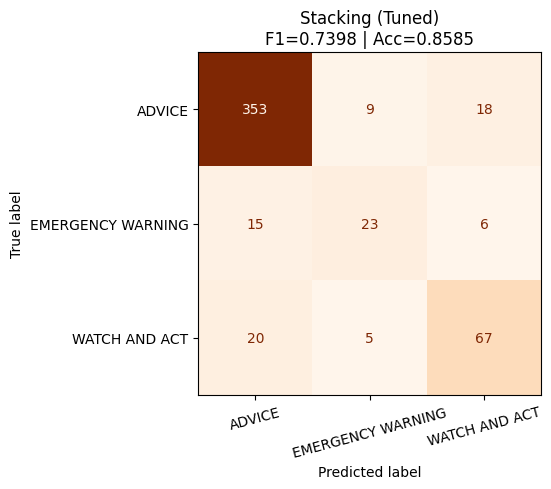

In [ ]:
fig, ax = plt.subplots(figsize=(6, 5))

for name, v in results.items():
    cm = confusion_matrix(y_test_encoded, v['y_pred'])
    disp = ConfusionMatrixDisplay(
        confusion_matrix = cm,
        display_labels   = target_encoder.classes_
    )
    disp.plot(cmap='Oranges', ax=ax, colorbar=False)
    ax.set_title(f'{name}\nF1={v["test_f1"]} | Acc={v["test_acc"]}')
    ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()